In [1]:
import numpy as np
from scipy.optimize import bisect
from InfAdjFPFiniteDiffApp import InfAdjFPFiniteDiff_ScipySp
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigs

In [2]:
dim = 2
mpl = 1.221e19
Pi = 100**0.5
M = 1e16 / mpl
phic = np.sqrt(2) * M
# phic = (3 * beta)**(-0.5)
# M = phic / 2**0.5
Lambda = (1e-15)**0.25
nWaterfall = 1
psic = (nWaterfall * Lambda**4 * Pi / 48 / 2**0.5 / np.pi**1.5)**0.5
beta = M**(-3) * Lambda

def infPotFunc(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * ((1 - (psi / M)**2)**2 + 2 * (phi * psi / phic / M)**2 + beta * (phi - phic)**3))
    
def infPotDerivFunc_phi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (4 * phi * (psi / phic / M)**2 + 3 * beta * (phi - phic)**2))
    
def infPotDerivFunc_psi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (-4 * psi / M**2 * (1 - (psi / M)**2) + 4 * psi * (phi / phic / M)**2))

def infPotDeriv2Func_phi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (4 * (psi / phic / M)**2 + 6 * beta * (phi - phic)))

def infPotDeriv2Func_psi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (-4 / M**2 + 12 * (psi / M / M)**2 + 4 * (phi / phic / M)**2))

def infPotDeriv2Func_phipsi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (8 * phi * psi / (phic * M)**2))

def eta_psi(Phi):
    return infPotDeriv2Func_psi(Phi) / infPotFunc(Phi)

def etaCl_phi(Phi):
    v = infPotFunc(Phi) / 24 / np.pi**2
    vDer = infPotDerivFunc_phi(Phi) / 24 / np.pi**2
    vDer2 = infPotDeriv2Func_phi(Phi) / 24 / np.pi**2
    return abs(2 * v - vDer2 * v**2 / vDer**2)

def etaCl_psi(Phi):
    v = infPotFunc(Phi) / 24 / np.pi**2
    vDer = infPotDerivFunc_psi(Phi) / 24 / np.pi**2
    vDer2 = infPotDeriv2Func_psi(Phi) / 24 / np.pi**2
    return abs(2 * v - vDer2 * v**2 / vDer**2)


infPotentialDerivFuncs = [infPotDerivFunc_phi, infPotDerivFunc_psi]
infPotentialDeriv2Funcs = [[infPotDeriv2Func_phi, infPotDeriv2Func_phipsi], [infPotDeriv2Func_phipsi, infPotDeriv2Func_psi]]

nGrid = 1000

In [3]:
deltaPhiWell = 2 * (2 / 3 * Lambda**4 / beta) ** (1 / 3)
phiLargeEtaMax = bisect(lambda phi: etaCl_phi([phi, 0]) - 0.1, phic + 0.01 * deltaPhiWell, phic + 10 * deltaPhiWell) 
phiLargeEtaMin = phic - (phiLargeEtaMax - phic)

# 以下は1912.05399に準拠。下限はad hoc
phimax = phic + beta**(-1/3)
phimin = phic - beta**(-1/3)

In [4]:
psiLargeEtaMax = bisect(lambda psi: etaCl_psi([phiLargeEtaMax, psi]) - 0.1, 0.0001 * psic, 1000 * psic)
psiLargeEtaMin = -psiLargeEtaMax 

psimax = bisect(lambda psi: eta_psi([phic, psi]) - 1, 0, M)
psimin = -psimax

In [5]:
customGrid_phi = np.concatenate([phic - np.exp(np.linspace(np.log(phic - phimin), np.log(phic - phiLargeEtaMin), nGrid // 4, endpoint=False)),
                                 np.linspace(phiLargeEtaMin, phiLargeEtaMax, nGrid // 2),
                                 phic + np.exp(np.linspace(np.log(phiLargeEtaMax - phic), np.log(phimax - phic), nGrid // 4 + 1)[1:])])
customGrid_psi = np.concatenate([-np.exp(np.linspace(np.log(psimax), np.log(psiLargeEtaMax), nGrid // 4 + 1))[:-1],
                                 np.linspace(psiLargeEtaMin, psiLargeEtaMax, nGrid // 2),
                                 np.exp(np.linspace(np.log(psiLargeEtaMax), np.log(psimax), nGrid // 4 + 1))[1:]])

In [6]:
phic

0.0011582420658256308

In [7]:
customGrid_phi

array([-1.34058809e-02, -1.26843327e-02, -1.19985320e-02, -1.13467079e-02,
       -1.07271770e-02, -1.01383394e-02, -9.57867450e-03, -9.04673701e-03,
       -8.54115322e-03, -8.06061750e-03, -7.60388889e-03, -7.16978792e-03,
       -6.75719354e-03, -6.36504028e-03, -5.99231540e-03, -5.63805638e-03,
       -5.30134836e-03, -4.98132181e-03, -4.67715030e-03, -4.38804831e-03,
       -4.11326925e-03, -3.85210354e-03, -3.60387672e-03, -3.36794776e-03,
       -3.14370740e-03, -2.93057655e-03, -2.72800481e-03, -2.53546905e-03,
       -2.35247206e-03, -2.17854126e-03, -2.01322749e-03, -1.85610384e-03,
       -1.70676454e-03, -1.56482394e-03, -1.42991548e-03, -1.30169076e-03,
       -1.17981867e-03, -1.06398447e-03, -9.53889027e-04, -8.49248025e-04,
       -7.49791237e-04, -6.55261822e-04, -5.65415664e-04, -4.80020741e-04,
       -3.98856526e-04, -3.21713418e-04, -2.48392200e-04, -1.78703524e-04,
       -1.12467424e-04, -4.95128498e-05,  1.03227754e-05,  6.71939730e-05,
        1.21247609e-04,  

<ipython-input-8-f50d7e0f0079>:7: RuntimeWarning: divide by zero encountered in log10
  cntr1 = ax1.contourf(customGrid_phi, customGrid_psi, np.log10(etaCls.T), levels=np.linspace(-5, 5, 11))


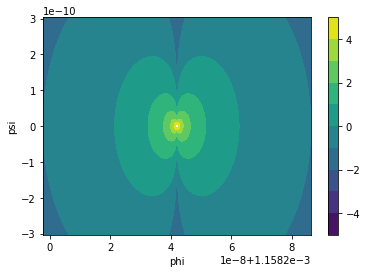

In [8]:
etaCls = np.zeros((nGrid, nGrid))
for i in range(nGrid):
    for j in range(nGrid):
        etaCls[i,j] = etaCl_phi([customGrid_phi[i], customGrid_psi[j]])

fig, ax1 = plt.subplots(1)
cntr1 = ax1.contourf(customGrid_phi, customGrid_psi, np.log10(etaCls.T), levels=np.linspace(-5, 5, 11))
fig.colorbar(cntr1, ax=ax1)
ax1.set_xlabel("phi")
ax1.set_ylabel("psi")
ax1.set_xlim([phiLargeEtaMin, phiLargeEtaMax])
ax1.set_ylim([psiLargeEtaMin, psiLargeEtaMax])
plt.show()

<ipython-input-9-fa15fc95bb6a>:7: RuntimeWarning: divide by zero encountered in log10
  cntr1 = ax1.contourf(customGrid_phi, customGrid_psi, np.log10(etaCls.T), levels=np.linspace(-5, 5, 11))


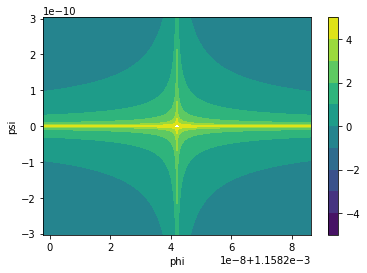

In [9]:
etaCls = np.zeros((nGrid, nGrid))
for i in range(nGrid):
    for j in range(nGrid):
        etaCls[i,j] = etaCl_psi([customGrid_phi[i], customGrid_psi[j]])

fig, ax1 = plt.subplots(1)
cntr1 = ax1.contourf(customGrid_phi, customGrid_psi, np.log10(etaCls.T), levels=np.linspace(-5, 5, 11))
fig.colorbar(cntr1, ax=ax1)
ax1.set_xlabel("phi")
ax1.set_ylabel("psi")
ax1.set_xlim([phiLargeEtaMin, phiLargeEtaMax])
ax1.set_ylim([psiLargeEtaMin, psiLargeEtaMax])
plt.show()

In [10]:
fpFinDiff_NeuDir = InfAdjFPFiniteDiff_ScipySp(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    [nGrid, nGrid],
    [phimax, psimax],
    [phimin, -psimax],
    ["Neumann0OriFunc", "Dirichlet"],
    ["Dirichlet", "Dirichlet"],
    customGrid=[customGrid_phi, customGrid_psi],
    set0OutOfInfRegion=False
)

# # ポテンシャルが一定以下ならインフレーション領域外として、当該点に対応する行列の要素を0とする
# customGrid_phi_woEnd = customGrid_phi[1:-1]
# customGrid_psi_woEnd = customGrid_psi[1:-1]
# vTh = (1 - 4.746948205088901201275e-16) * Lambda**4
# maskMat = np.full((len(customGrid_phi_woEnd), len(customGrid_psi_woEnd)), False)
# for i1 in range(len(customGrid_phi_woEnd)):
#     for i2 in range(len(customGrid_psi_woEnd)):
#         if infPotFunc([customGrid_phi_woEnd[i1], customGrid_phi_woEnd[i2]]) < vTh:
#             maskMat[i1, i2] = True
#             fpFinDiff_NeuNeu[i1, i2] = 0

eigVals_NeuDir, eigVecs_NeuDir = eigs(fpFinDiff_NeuDir, 10, sigma=0, which='LM')
eigVecsSort_NeuDir = eigVecs_NeuDir.T[np.argsort(np.abs(eigVals_NeuDir))]
eigValsSort_NeuDir = eigVals_NeuDir[np.argsort(np.abs(eigVals_NeuDir))]

In [11]:
np.set_printoptions(formatter={'float': '{:.15e}'.format})
print(fpFinDiff_NeuDir)
np.set_printoptions()

  (0, 0)	1.1004254229273404e+24
  (0, 1)	-0.02479446706739224
  (0, 998)	-1.7339003902414998e-12
  (1, 0)	-0.02610924657830622
  (1, 1)	1.0815495171338355e+24
  (1, 2)	-0.02679243616725598
  (1, 999)	-1.7338954068271613e-12
  (2, 1)	-0.0274936229635422
  (2, 2)	1.0636236699293875e+24
  (2, 3)	-0.028213043167594043
  (2, 1000)	-1.733890674361606e-12
  (3, 2)	-0.02895140877304614
  (3, 3)	1.0466000856931203e+24
  (3, 4)	-0.02970898079558349
  (3, 1001)	-1.733886180207859e-12
  (4, 3)	-0.030486496693538413
  (4, 4)	1.0304333710957785e+24
  (4, 5)	-0.031284243613732096
  (4, 1002)	-1.7338819123652998e-12
  (5, 4)	-0.03210298582951313
  (5, 5)	1.0150804145737818e+24
  (5, 6)	-0.032943038004496425
  (5, 1003)	-1.7338778594376246e-12
  (6, 5)	-0.03380519264896686
  (6, 6)	1.00050027182887e+24
  :	:
  (995997, 995997)	5.5748685138496795e+20
  (995997, 995998)	-0.44436299463157636
  (995998, 995000)	-3.171377908781798e-11
  (995998, 995997)	-0.43303013155248904
  (995998, 995998)	5.701134558977

In [12]:
fpFinDiff_DirDir = InfAdjFPFiniteDiff_ScipySp(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    [nGrid, nGrid],
    [phimax, psimax],
    [phimin, -psimax],
    ["Dirichlet", "Dirichlet"],
    ["Dirichlet", "Dirichlet"],
    customGrid=[customGrid_phi, customGrid_psi],
    set0OutOfInfRegion=False
)

# for i1 in range(len(customGrid_phi_woEnd)):
#     for i2 in range(len(customGrid_psi_woEnd)):
#         if maskMat[i1, i2]: fpFinDiff_DirDir[i1, i2] = 0

eigVals_DirDir, eigVecs_DirDir = eigs(fpFinDiff_DirDir, 10, sigma=0, which='LM')
eigVecsSort_DirDir = eigVecs_DirDir.T[np.argsort(np.abs(eigVals_DirDir))]
eigValsSort_DirDir = eigVals_DirDir[np.argsort(np.abs(eigVals_DirDir))]

In [13]:
np.set_printoptions(formatter={'float': '{:.15e}'.format})
print(fpFinDiff_DirDir)
np.set_printoptions()

  (0, 0)	1.1004254229273404e+24
  (0, 1)	-0.02479446706739224
  (0, 998)	-1.7339003902414998e-12
  (1, 0)	-0.02610924657830622
  (1, 1)	1.0815495171338355e+24
  (1, 2)	-0.02679243616725598
  (1, 999)	-1.7338954068271613e-12
  (2, 1)	-0.0274936229635422
  (2, 2)	1.0636236699293875e+24
  (2, 3)	-0.028213043167594043
  (2, 1000)	-1.733890674361606e-12
  (3, 2)	-0.02895140877304614
  (3, 3)	1.0466000856931203e+24
  (3, 4)	-0.02970898079558349
  (3, 1001)	-1.733886180207859e-12
  (4, 3)	-0.030486496693538413
  (4, 4)	1.0304333710957785e+24
  (4, 5)	-0.031284243613732096
  (4, 1002)	-1.7338819123652998e-12
  (5, 4)	-0.03210298582951313
  (5, 5)	1.0150804145737818e+24
  (5, 6)	-0.032943038004496425
  (5, 1003)	-1.7338778594376246e-12
  (6, 5)	-0.03380519264896686
  (6, 6)	1.00050027182887e+24
  :	:
  (995997, 995997)	5.574868513849678e+20
  (995997, 995998)	-0.44436299463157636
  (995998, 995000)	-1.5170910204836564e-11
  (995998, 995997)	-0.43303013155248904
  (995998, 995998)	5.701134558977

c:\Users\koich\anaconda3\lib\site-packages\numpy\core\_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


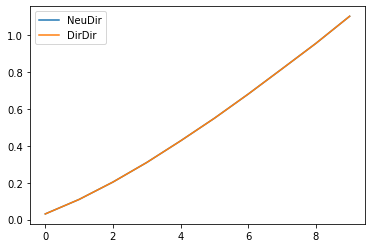

In [14]:
ax = plt.gca()
plt.plot(eigValsSort_NeuDir, label = "NeuDir")
plt.plot(eigValsSort_DirDir, label = "DirDir")
plt.legend()
plt.show()

In [15]:
np.set_printoptions(formatter={'float': '{:.30e}'.format})
print(eigValsSort_NeuDir[0:10])
print(eigValsSort_DirDir[0:10])
np.set_printoptions()

[0.030887  +0.j 0.10944264+0.j 0.20365521+0.j 0.3098257 +0.j
 0.42693164+0.j 0.54963441+0.j 0.68066275+0.j 0.81756003+0.j
 0.95547353+0.j 1.10284036+0.j]
[0.030887  +0.j 0.10944264+0.j 0.20365521+0.j 0.3098257 +0.j
 0.42693164+0.j 0.54963441+0.j 0.68066275+0.j 0.81756003+0.j
 0.95547353+0.j 1.10284036+0.j]


c:\Users\koich\anaconda3\lib\site-packages\matplotlib\contour.py:1454: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmax = float(z.max())
c:\Users\koich\anaconda3\lib\site-packages\matplotlib\contour.py:1455: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmin = float(z.min())
c:\Users\koich\anaconda3\lib\site-packages\numpy\ma\core.py:2825: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,


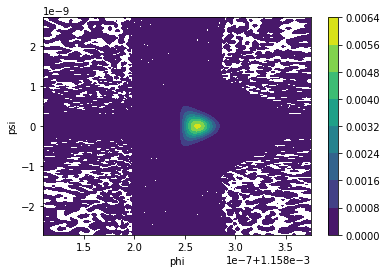

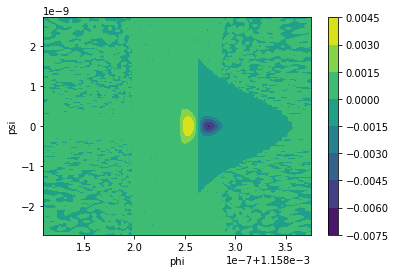

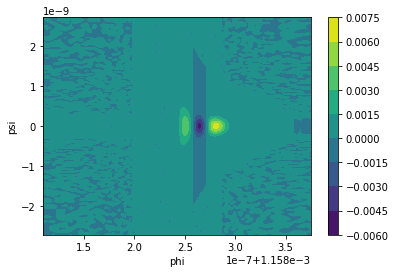

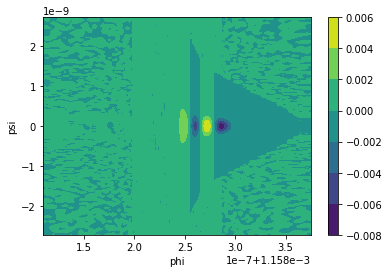

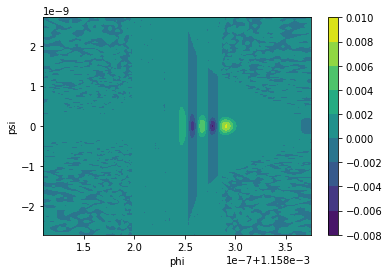

In [16]:
# 固有関数のプロット
customGrid_phi_woEnd = customGrid_phi[1:-1]
customGrid_psi_woEnd = customGrid_psi[1:-1]

for iEig in range(5):   
    fig, ax1 = plt.subplots(1)
    cntr1 = ax1.contourf(customGrid_phi_woEnd, customGrid_psi_woEnd, np.reshape(eigVecsSort_NeuDir[iEig], (nGrid-2, nGrid-2)).T)
    fig.colorbar(cntr1, ax=ax1)
    ax1.set_xlabel("phi")
    ax1.set_ylabel("psi")
    ax1.set_xlim([2 * phiLargeEtaMin - phiLargeEtaMax, 2 * phiLargeEtaMax - phiLargeEtaMin])
    ax1.set_ylim([5 * psiLargeEtaMin - 4 * psiLargeEtaMax, 5 * psiLargeEtaMax - 4 * psiLargeEtaMin])
    plt.show()

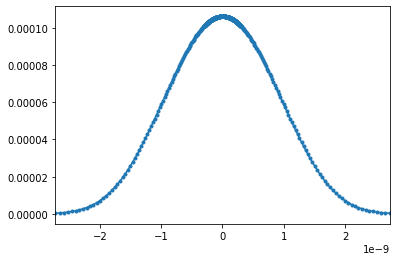

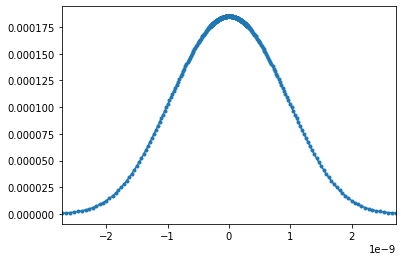

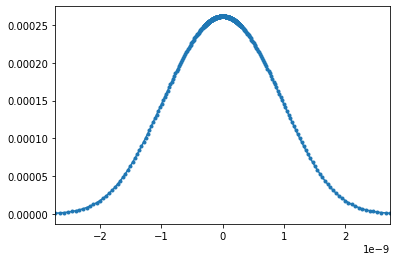

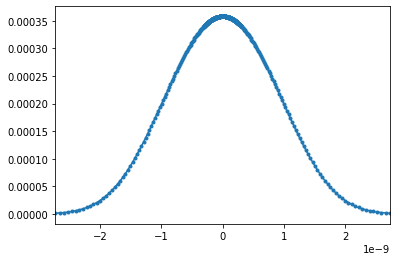

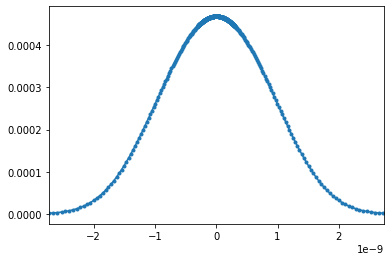

In [17]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_psi_woEnd, np.reshape(eigVecsSort_NeuDir[iEig], (nGrid-2, nGrid-2))[nGrid // 2,:], marker='.')
    ax.set_xlim([5 * psiLargeEtaMin - 4 * psiLargeEtaMax, 5 * psiLargeEtaMax - 4 * psiLargeEtaMin])
    plt.show()

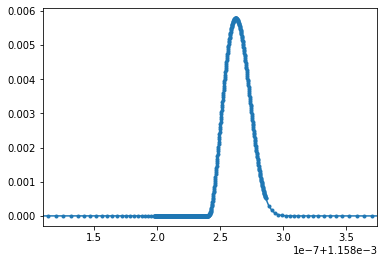

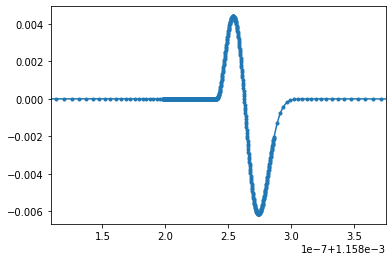

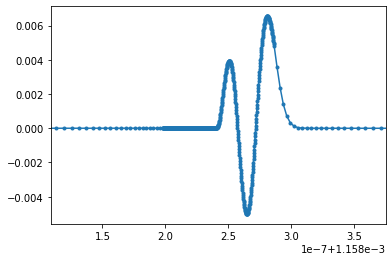

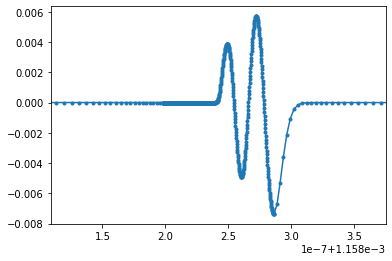

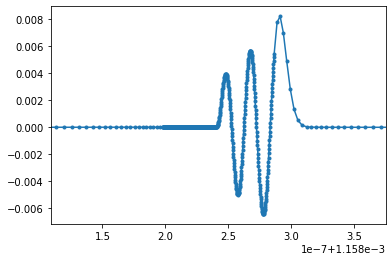

In [18]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_phi_woEnd, np.reshape(eigVecsSort_NeuDir[iEig], (nGrid-2, nGrid-2))[:,nGrid//2], marker=".")
    ax.set_xlim([2 * phiLargeEtaMin - phiLargeEtaMax, 2 * phiLargeEtaMax - phiLargeEtaMin])
    plt.show()

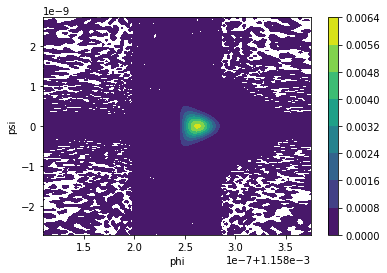

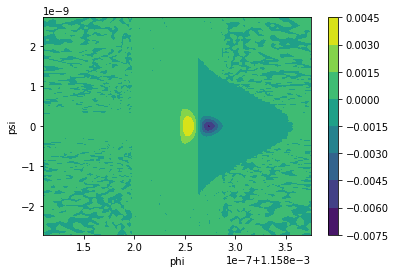

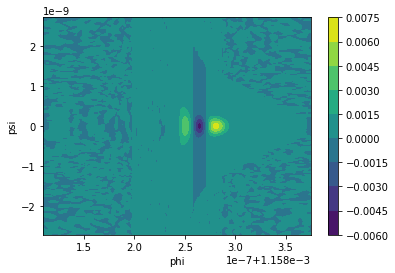

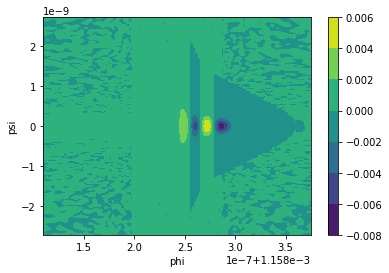

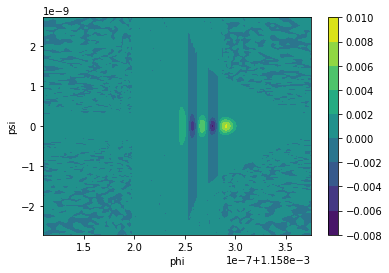

In [19]:
# 固有関数のプロット
for iEig in range(5):   
    fig, ax1 = plt.subplots(1)
    cntr1 = ax1.contourf(customGrid_phi_woEnd, customGrid_psi_woEnd, np.reshape(eigVecsSort_DirDir[iEig], (nGrid-2, nGrid-2)).T)
    fig.colorbar(cntr1, ax=ax1)
    ax1.set_xlabel("phi")
    ax1.set_ylabel("psi")
    ax1.set_xlim([2 * phiLargeEtaMin - phiLargeEtaMax, 2 * phiLargeEtaMax - phiLargeEtaMin])
    ax1.set_ylim([5 * psiLargeEtaMin - 4 * psiLargeEtaMax, 5 * psiLargeEtaMax - 4 * psiLargeEtaMin])
    plt.show()

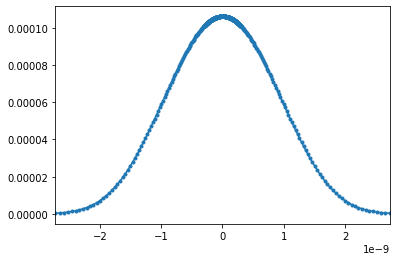

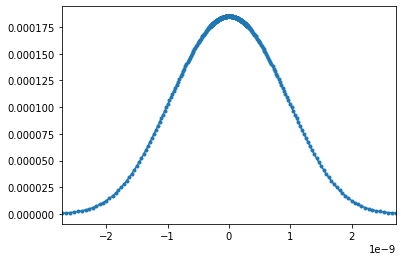

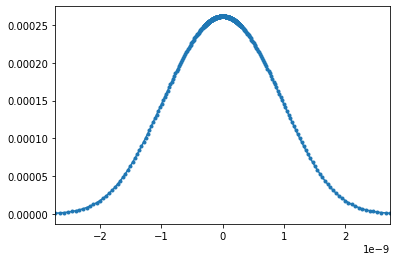

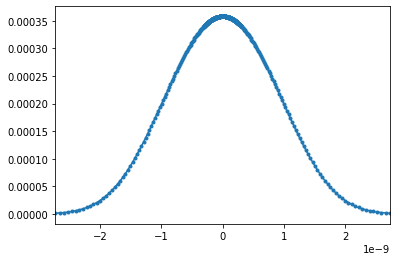

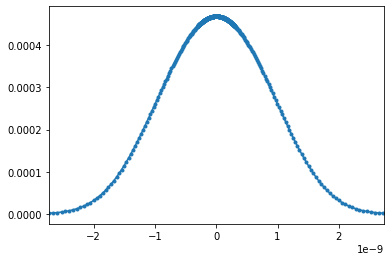

In [20]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_psi_woEnd, np.reshape(eigVecsSort_DirDir[iEig], (nGrid-2, nGrid-2))[nGrid//2,:],marker=".")
    ax.set_xlim([5 * psiLargeEtaMin - 4 * psiLargeEtaMax, 5 * psiLargeEtaMax - 4 * psiLargeEtaMin])
    plt.show()

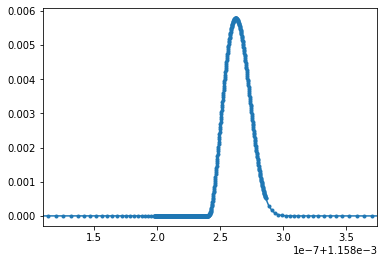

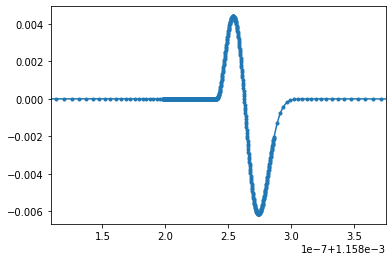

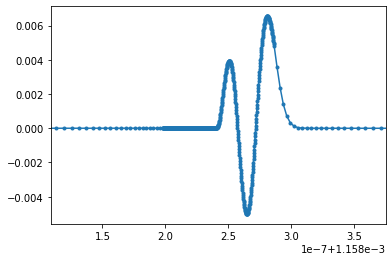

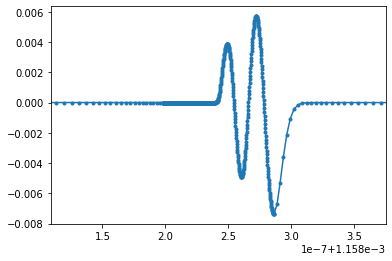

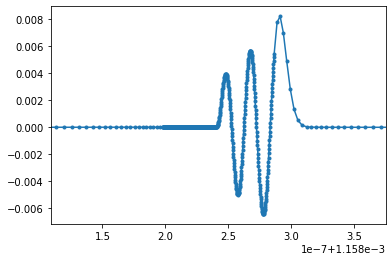

In [21]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_phi_woEnd, np.reshape(eigVecsSort_DirDir[iEig], (nGrid-2, nGrid-2))[:,nGrid//2], marker=".")
    ax.set_xlim([2 * phiLargeEtaMin - phiLargeEtaMax, 2 * phiLargeEtaMax - phiLargeEtaMin])
    plt.show()